In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

In [23]:
def format_ticks(y, _):
        # Format with 2 decimals
        s = f'{y:.3f}'
        # Remove trailing zeros and dot if needed
        if '.' in s:
            s = s.rstrip('0').rstrip('.')
        # Remove leading zero before decimal point
        if s.startswith('0.') or s.startswith('-0.'):
            s = s.replace('0.', '.')
        return s

In [52]:
corr_data = pd.read_csv("../../results/random_targets_wasserstein_no-benjamini_occurence-adjusted.csv")
corr_data["Type"] = "Adjusted"

non_corr_data = pd.read_csv("../../results/random_targets_wasserstein_all_tissues_with_samples.csv", index_col=0)
non_corr_data = non_corr_data[non_corr_data['tissue'].isin(["Breast", "Kidney", "Testis"])]
non_corr_data["Type"] = "Non-adjusted"

data = pd.concat([corr_data, non_corr_data], ignore_index=True)
data = data.rename(columns={"tissue": "Tissue"})
data = data.replace({"Non-adjusted": "Unadjusted"})
data

,Tissue,num_non_tfs,num_tfs,mae,f1_005,f1_001,abs_time_saving,rel_time_saving,abs_emission_saving,rel_emission_saving,total_runtime,correlation,tp_001,Type,num_samples
0,Breast,1,-1,0.126420,0.819639,0.567619,320607.596895,190.321377,11.956733,312.437359,1693.456926,0.873892,57174.0,Adjusted,NaN
1,Breast,2,-1,0.101386,0.836925,0.566823,320655.584961,195.871865,11.952158,279.166986,1645.468861,0.876733,55157.0,Adjusted,NaN
2,Breast,3,-1,0.086255,0.854141,0.584343,320844.588775,221.289934,11.953017,284.867174,1456.465046,0.877325,53752.0,Adjusted,NaN
3,Breast,4,-1,0.092677,0.852950,0.588013,320829.303093,218.991605,11.954306,293.859697,1471.750729,0.878491,56591.0,Adjusted,NaN
4,Breast,5,-1,0.078012,0.857411,0.579849,320846.249551,221.542554,11.958588,328.299472,1454.804271,0.879378,53400.0,Adjusted,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,Testis,60,-1,0.012270,0.861300,0.892656,328557.476628,105.963107,13.026797,131.842873,3130.218669,NaN,NaN,Unadjusted,361.0
110,Testis,70,-1,0.012344,0.860672,0.893029,327970.685092,89.235078,13.001992,105.546328,3717.010204,NaN,NaN,Unadjusted,361.0
111,Testis,80,-1,0.012400,0.859587,0.892732,328910.038977,119.412792,13.027113,132.261897,2777.656320,NaN,NaN,Unadjusted,361.0
112,Testis,90,-1,0.012404,0.860611,0.891464,328775.125631,113.881463,13.026500,131.449781,2912.569666,NaN,NaN,Unadjusted,361.0


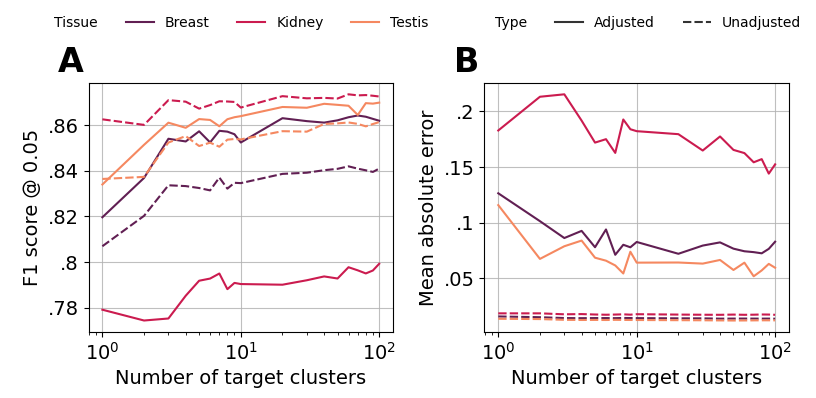

In [55]:
# Create mosaic with two panels
fig, axs = plt.subplot_mosaic([['A', 'B']])
fig.set_size_inches(8, 4)
label_fontsize = 14

### Plot A
sns.lineplot(
    data=data,
    x="num_non_tfs",
    y="f1_005",
    hue="Tissue",
    style="Type",
    legend=False,
    palette=sns.color_palette("rocket", 3),
    ax=axs['A']
)

axs['A'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
axs['A'].set_ylabel('F1 score @ 0.05', fontsize=label_fontsize)
axs['A'].tick_params(axis='both', labelsize=label_fontsize)
axs['A'].yaxis.set_major_formatter(FuncFormatter(format_ticks))
axs['A'].grid(True, alpha=0.8)
axs['A'].set_xscale('log')

### Plot B (creates legend)
sns.lineplot(
    data=data,
    x="num_non_tfs",
    y="mae",
    hue="Tissue",
    style="Type",
    palette=sns.color_palette("rocket", 3),
    legend='auto',
    ax=axs['B']
)

axs['B'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
axs['B'].set_ylabel("Mean absolute error", fontsize=label_fontsize)
axs['B'].tick_params(axis='both', labelsize=label_fontsize)
axs['B'].yaxis.set_major_formatter(FuncFormatter(format_ticks))
axs['B'].grid(True, alpha=0.8)
axs['B'].set_xscale('log')

# -----------------------------
# Shared single-line legend
# -----------------------------
handles, labels = axs['B'].get_legend_handles_labels()
axs['B'].legend_.remove()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=len(labels),      # <- forces one row
    frameon=False,
    fontsize=10.
)

# -----------------------------
# Panel labels
# -----------------------------
for key, label in {'A': 'A', 'B': 'B'}.items():
    axs[key].text(
        -0.1, 1.15, label,
        transform=axs[key].transAxes,
        fontsize=24,
        fontweight='bold',
        va='top',
        ha='left'
    )

fig.tight_layout()
fig.subplots_adjust(top=0.80, wspace=0.3)

plt.savefig(
    "supplement_pvalue_adjustment_for_occurences.pdf",
    format='pdf',
    bbox_inches='tight'
)
plt.savefig("supplement_pvalues_occurence_adjusted.pdf")

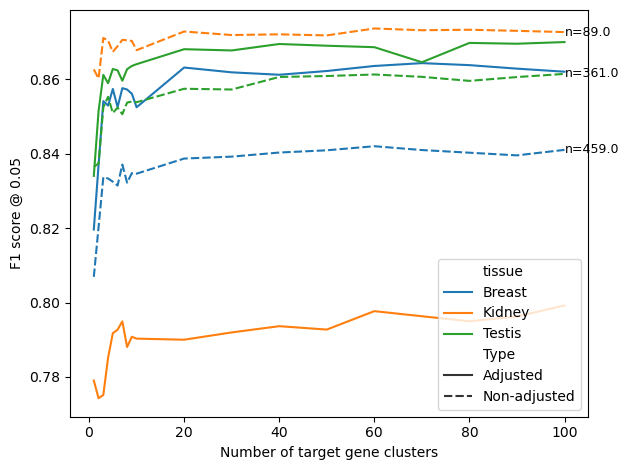

In [17]:
ax = sns.lineplot(
    data=data,
    x="num_non_tfs",
    y="f1_005",
    hue="tissue",
    style="Type",
)

ax.set_ylabel("F1 score @ 0.05")
ax.set_xlabel("Number of target gene clusters")

# annotate only for Type == "Non-adjusted"
data_non_adj = data[data["Type"] == "Non-adjusted"]

for tissue, df_sub in data_non_adj.groupby("tissue"):
    df_sub = df_sub.sort_values("num_non_tfs")
    
    x_last = df_sub["num_non_tfs"].iloc[-1]
    y_last = df_sub["f1_005"].iloc[-1]
    n = df_sub["num_samples"].iloc[-1]
    
    ax.text(
        x_last,
        y_last,
        f"n={n}",
        fontsize=9,
        va="center",
        ha="left"
    )

plt.tight_layout()

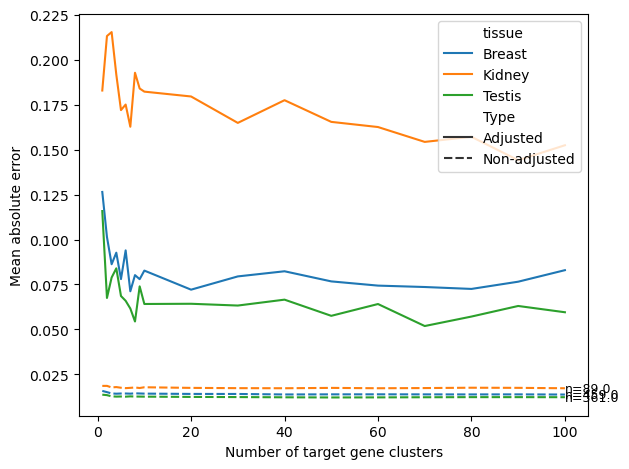

In [22]:
ax = sns.lineplot(
    data=data,
    x="num_non_tfs",
    y="mae",
    hue="tissue",
    style="Type",
)

ax.set_ylabel("Mean absolute error")
ax.set_xlabel("Number of target gene clusters")

# annotate only for Type == "Non-adjusted"
data_non_adj = data[data["Type"] == "Non-adjusted"]

for tissue, df_sub in data_non_adj.groupby("tissue"):
    df_sub = df_sub.sort_values("num_non_tfs")
    
    x_last = df_sub["num_non_tfs"].iloc[-1]
    y_last = df_sub["mae"].iloc[-1]
    n = df_sub["num_samples"].iloc[-1]
    
    ax.text(
        x_last,
        y_last,
        f"n={n}",
        fontsize=9,
        va="center",
        ha="left"
    )

plt.tight_layout()